In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("Bengaluru_House_Data.csv")

# Audit
print("Shape:", df.shape)
print("Data types:\n", df.dtypes)
print("Missing values:\n", df.isnull().sum())

# Cleaning
df = df.dropna(subset=['location','size'])  # drop rows missing critical info
df['bath'] = df['bath'].fillna(df['bath'].median())
df['balcony'] = df['balcony'].fillna(df['balcony'].median())


Shape: (13320, 9)
Data types:
 area_type        object
availability     object
location         object
size             object
society          object
total_sqft       object
bath            float64
balcony         float64
price           float64
dtype: object
Missing values:
 area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64


In [2]:
# Extract numeric BHK 
df['bhk'] = df['size'].str.extract(r'(\d+)').astype(int)

# total_sqft conversion
def convert_sqft(x):
    try:
        if '-' in str(x):
            a, b = x.split('-')
            return (float(a) + float(b)) / 2
        return float(x)
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)
df = df.dropna(subset=['total_sqft'])

# price per sqft
df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft']


In [3]:
# remove outliers
def remove_pps_outliers(df):
    out = pd.DataFrame()
    
    for loc, subdf in df.groupby('location'):
        m = subdf['price_per_sqft'].mean()
        st = subdf['price_per_sqft'].std()
        
        reduced = subdf[
            (subdf['price_per_sqft'] >= (m - 3*st)) &
            (subdf['price_per_sqft'] <= (m + 3*st))
        ]
        
        out = pd.concat([out, reduced], ignore_index=True)
    
    return out

df = remove_pps_outliers(df)


 Q3 Answer
Outliers were removed using location-wise mean ± 3 standard deviations.
This is better than global because prices vary across locations.

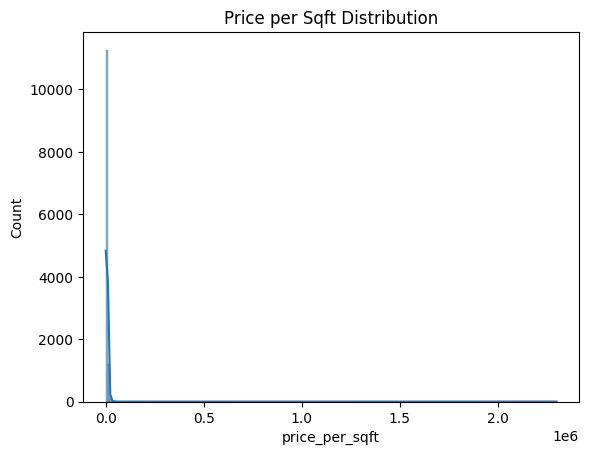

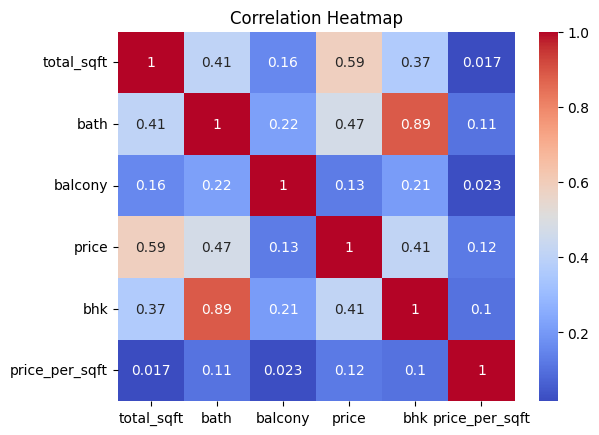

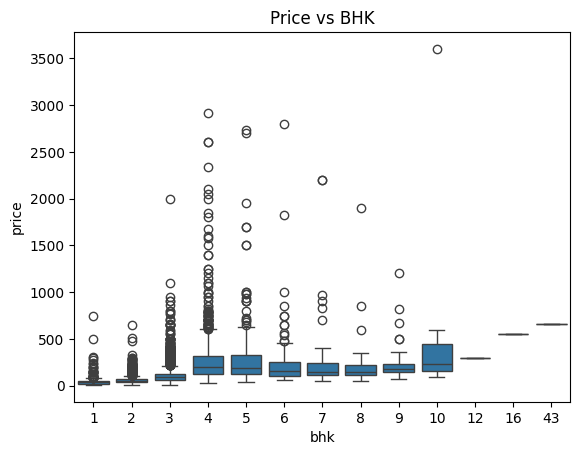

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.histplot(df['price_per_sqft'], kde=True)
plt.title("Price per Sqft Distribution")
plt.show()

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

sns.boxplot(x='bhk', y='price', data=df)
plt.title("Price vs BHK")
plt.show()


Histogram: Right-skewed with outliers  
Heatmap: Size and bath positively correlate with price  
Boxplot: Price increases with BHK

In [5]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler

# Top 20 locations
top_locations = df['location'].value_counts().nlargest(20).index
df['location'] = df['location'].apply(lambda x: x if x in top_locations else 'Other')

# OneHotEncoder for area_type
encoder = OneHotEncoder(drop='first', sparse_output=False)

encoded = encoder.fit_transform(df[['area_type']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['area_type']))

df = df.reset_index(drop=True)
encoded_df = encoded_df.reset_index(drop=True)

df = pd.concat([df.drop('area_type', axis=1), encoded_df], axis=1)

# Label encode location
le = LabelEncoder()
df['location'] = le.fit_transform(df['location'])

# Scaling
scaler = MinMaxScaler()
df[['total_sqft', 'bath']] = scaler.fit_transform(df[['total_sqft', 'bath']])

One-hot for area_type (no order)  
Label encoding for location (reduce dimensions)  
MinMax scaling for numerical features

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = df.drop(['price', 'size'], axis=1)
y = df['price']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(name)
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))

Linear
RMSE: 266.23912424511434
MAE: 32.82775593303045
R2: -3.2734940141015025
Ridge
RMSE: 240.41292869989664
MAE: 33.5686518165721
R2: -2.484616477585246
Lasso
RMSE: 234.66871543540418
MAE: 45.572978816094626
R2: -2.320089108091518


Regularisation reduces overfitting by penalizing large coefficients.


 LogisticRegression
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1799
           1       0.90      0.90      0.90       727

    accuracy                           0.94      2526
   macro avg       0.93      0.93      0.93      2526
weighted avg       0.94      0.94      0.94      2526


 GaussianNB
              precision    recall  f1-score   support

           0       0.96      0.37      0.53      1799
           1       0.38      0.97      0.55       727

    accuracy                           0.54      2526
   macro avg       0.67      0.67      0.54      2526
weighted avg       0.80      0.54      0.53      2526



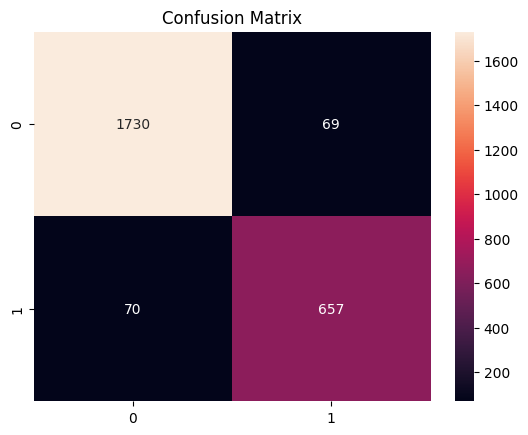

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Target
df['high_value'] = df['price'].apply(lambda x: 1 if x >= 100 else 0)

X = df.drop(['price', 'high_value', 'size'], axis=1)
y = df['high_value']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Models
log = LogisticRegression(max_iter=5000)
nb = GaussianNB()

models = [log, nb]
best_model = None
best_score = 0

for model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print("\n", model.__class__.__name__)
    print(classification_report(y_test, y_pred))
    
    acc = model.score(X_test, y_test)
    if acc > best_score:
        best_score = acc
        best_model = model

# Confusion matrix
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

Logistic Regression performed better as it models feature relationships better.

Best Params: {'max_depth': None, 'n_estimators': 50}
Best Score: 0.9767349767349768
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1799
           1       0.97      0.96      0.97       727

    accuracy                           0.98      2526
   macro avg       0.98      0.97      0.98      2526
weighted avg       0.98      0.98      0.98      2526



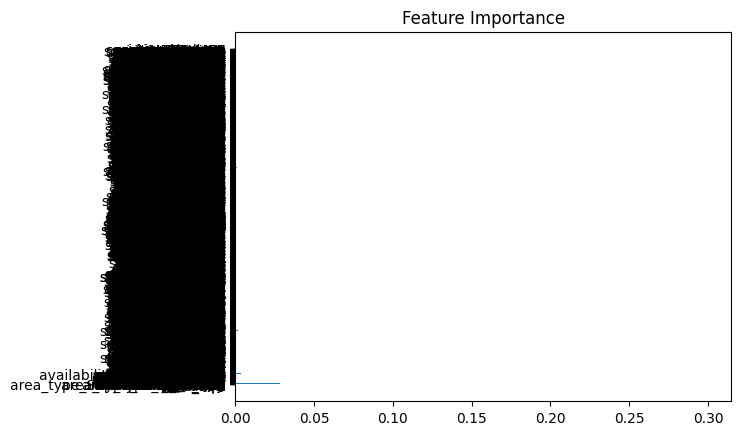

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

params = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10]
}

grid = GridSearchCV(rf, params, cv=3, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

# Feature importance
plt.barh(X.columns, best_model.feature_importances_)
plt.title("Feature Importance")
plt.show()

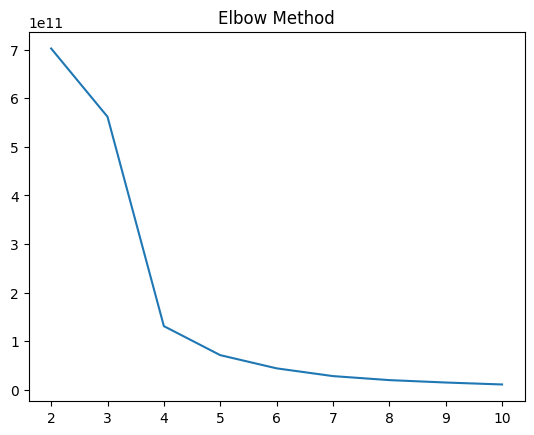

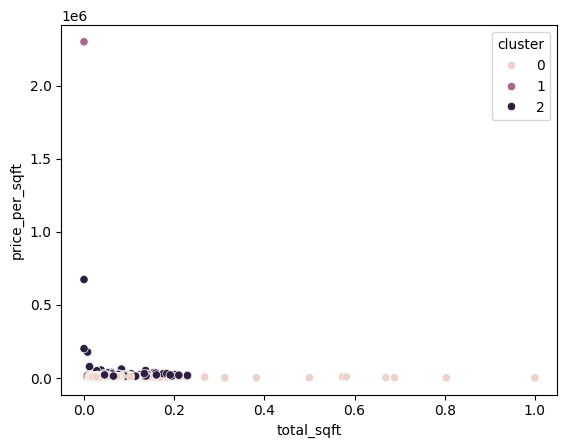

In [9]:
from sklearn.cluster import KMeans

X_cluster = df[['total_sqft', 'bath', 'price_per_sqft']]

wcss = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_cluster)
    wcss.append(kmeans.inertia_)

plt.plot(range(2,11), wcss)
plt.title("Elbow Method")
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_cluster)

sns.scatterplot(x='total_sqft', y='price_per_sqft', hue='cluster', data=df)
plt.show()

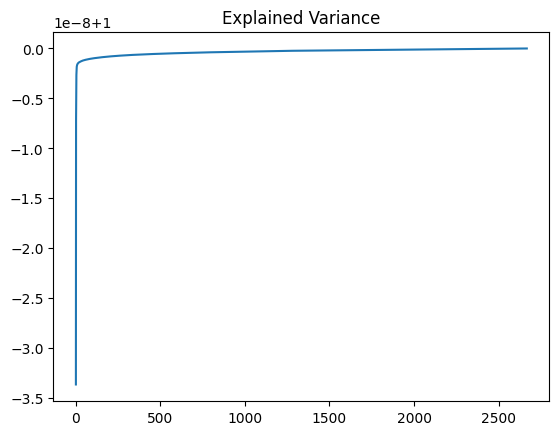

Accuracy after PCA: 0.9196357878068092


In [10]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.title("Explained Variance")
plt.show()

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

rf.fit(X_train, y_train)
print("Accuracy after PCA:", rf.score(X_test, y_test))

In [12]:
import joblib
joblib.dump(best_model, "model.pkl")

['model.pkl']